# Actor Critic using LSTM
Implemention, training, and evaluation of an Actor-Critic agent with an LSTM for the Blackjack-v1 environment to demonstrate reinforcement learning in partial observable environment.

Gymnasium installation and import of libraries.

In [ ]:
!pip install gymnasium

In [ ]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

In [ ]:
import torch.nn.functional as F

class ActorCriticLSTM(nn.Module):
    def __init__(self, observation_space, action_space, hidden_size=128, num_layers=1):
        super(ActorCriticLSTM, self).__init__()

        self.input_size = 3 # Blackjack: (sum, dealer, ace)
        self.action_size = action_space.n
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # Stacked LSTM: num_layers > 1 creates a 'Deep' RNN
        self.lstm = nn.LSTM(input_size=self.input_size,
                            hidden_size=self.hidden_size,
                            num_layers=self.num_layers,
                            batch_first=True)

        self.actor_head = nn.Linear(self.hidden_size, self.action_size)
        self.critic_head = nn.Linear(self.hidden_size, 1)

    def forward(self, x, hidden_state=None):
        lstm_out, new_hidden_state = self.lstm(x, hidden_state)
        last_step = lstm_out[:, -1, :]

        # Passing through ReLU before the heads
        activated = F.relu(last_step)

        actor_logits = self.actor_head(activated)
        critic_value = self.critic_head(activated)

        return actor_logits, critic_value, new_hidden_state

In [ ]:
import torch.distributions as distributions

def calculate_returns(rewards, gamma):
    returns = []
    R = 0
    for r in reversed(rewards):
        R = r + gamma * R
        returns.insert(0, R)
    return torch.tensor(returns, dtype=torch.float32)

def preprocess_obs(obs):
    # obs is (player_sum, dealer_card, usable_ace)
    # Convert to a tensor of shape (1, 1, 3)
    res = torch.tensor([obs[0], obs[1], float(obs[2])], dtype=torch.float32)
    return res.view(1, 1, 3)

def train_actor_critic_blackjack(model, optimizer, env, num_episodes, gamma=0.99):
    for episode in range(num_episodes):
        obs, _ = env.reset()
        hidden_state = None

        log_probs, values, rewards = [], [], []
        done, truncated = False, False
        episode_reward = 0

        while not (done or truncated):
            # Preprocess the Tuple into a Vector
            obs_tensor = preprocess_obs(obs).to(device)

            # Model Inference
            logits, val, hidden_state = model(obs_tensor, hidden_state)

            # Action Selection
            dist = torch.distributions.Categorical(logits=logits)
            action = dist.sample()

            next_obs, reward, done, truncated, _ = env.step(action.item())

            # Store for training
            log_probs.append(dist.log_prob(action))
            values.append(val)
            rewards.append(reward)

            obs = next_obs
            episode_reward += reward

        # --- Optimization Step (After Episode) ---
        if len(rewards) == 0: continue # Safety check

        returns = calculate_returns(rewards, gamma).to(device)
        values_tensor = torch.cat(values).view(-1)

        advantages = returns - values_tensor.detach()

        actor_loss = -(torch.stack(log_probs) * advantages).mean()
        critic_loss = F.mse_loss(values_tensor, returns)
        total_loss = actor_loss + critic_loss

        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        if episode % 1000 == 0:
            print(f"Episode {episode} | Reward: {episode_reward} | Loss: {total_loss.item():.4f}")

print("Training function 'train_actor_critic' defined.")

Training function 'train_actor_critic' defined.


Set up of environment and device

In [ ]:
env = gym.make("Blackjack-v1", sab=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


First train of the model

In [ ]:
model = ActorCriticLSTM(
    observation_space=env.observation_space,
    action_space=env.action_space,
    hidden_size=128,
    num_layers=1
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

train_actor_critic_blackjack(
    model=model,
    optimizer=optimizer,
    env=env,
    num_episodes=200_000,
    gamma=0.99
)

Episode 0 | Reward: -1.0 | Loss: 0.4097
Episode 1000 | Reward: -1.0 | Loss: 0.9193
Episode 2000 | Reward: -1.0 | Loss: 0.2124
Episode 3000 | Reward: -1.0 | Loss: 0.5662
Episode 4000 | Reward: -1.0 | Loss: 1.4654
Episode 5000 | Reward: 1.0 | Loss: 0.3084
Episode 6000 | Reward: 1.0 | Loss: 0.6894
Episode 7000 | Reward: -1.0 | Loss: 0.4894
Episode 8000 | Reward: 1.0 | Loss: 2.1910
Episode 9000 | Reward: -1.0 | Loss: 0.7250
Episode 10000 | Reward: -1.0 | Loss: 0.2069
Episode 11000 | Reward: 1.0 | Loss: 2.8869
Episode 12000 | Reward: -1.0 | Loss: 0.7135
Episode 13000 | Reward: 0.0 | Loss: 0.0030
Episode 14000 | Reward: 1.0 | Loss: 2.0342
Episode 15000 | Reward: 1.0 | Loss: 0.4083
Episode 16000 | Reward: -1.0 | Loss: 0.3630
Episode 17000 | Reward: -1.0 | Loss: 0.2926
Episode 18000 | Reward: 0.0 | Loss: 0.1071
Episode 19000 | Reward: -1.0 | Loss: 0.3851
Episode 20000 | Reward: -1.0 | Loss: 0.5299
Episode 21000 | Reward: 1.0 | Loss: 0.8019
Episode 22000 | Reward: 1.0 | Loss: 1.6297
Episode 230

First evaluation of the agent

In [ ]:
import numpy as np
import torch

def evaluate_agent(model, env, num_test_episodes, device):
    model.eval()  # Set to evaluation mode
    total_rewards = []
    wins = 0

    with torch.no_grad(): # Disable gradient calculation for efficiency
        for episode in range(num_test_episodes):
            observation, _ = env.reset()
            hidden_state = None # Reset memory for a new hand
            episode_reward = 0
            done = False
            truncated = False

            while not (done or truncated):
                # Preprocess the Tuple observation into a (1, 1, 3) tensor
                # Reuse the preprocess_obs function from the training step
                observation_tensor = preprocess_obs(observation).to(device)

                # Pass hidden_state and get the new one back
                actor_logits, _, hidden_state = model(observation_tensor, hidden_state)

                # Choose action greedily (highest probability)
                # actor_logits shape is (1, action_size), so argmax over dim 1
                action = torch.argmax(actor_logits, dim=1).item()

                observation, reward, done, truncated, _ = env.step(action)
                episode_reward += reward

            total_rewards.append(episode_reward)
            if episode_reward > 0:
                wins += 1

    avg_reward = np.mean(total_rewards)
    win_rate = wins / num_test_episodes

    print(f"\nEvaluation complete over {num_test_episodes} episodes:")
    print(f"Average Reward: {avg_reward:.4f}")
    print(f"Win Rate: {win_rate * 100:.2f}%")
    return avg_reward, win_rate

In [ ]:
num_test_episodes = 1000
avg_reward, win_rate = evaluate_agent(model, env, num_test_episodes, "cpu")

print(f"Agent evaluated with {num_test_episodes} episodes.")
print(f"Average reward over test episodes: {avg_reward:.4f}")
print(f"Win rate over test episodes: {win_rate:.4f}")


Evaluation complete over 1000 episodes:
Average Reward: -0.0430
Win Rate: 44.20%
Agent evaluated with 1000 episodes.
Average reward over test episodes: -0.0430
Win rate over test episodes: 0.4420


Creating a hand hyperparameter tuning

In [ ]:
configs = [
    {
        "name": "Shallow (1 Layer) gamma 0.99 and 128 hidden layers",
        "lr": 0.0005, "episodes": 10000, "gamma": 0.99,
        "hidden": 128, "layers": 1
    },
    {
        "name": "Deep (2 Layers) gamma 0.99 and 128 hidden layers",
        "lr": 0.0005, "episodes": 10000, "gamma": 0.99,
        "hidden": 128, "layers": 2
    },
    {
        "name": "Shallow (1 Layers) with gamma 0.99 and 128 hidden layers",
        "lr": 0.0005, "episodes": 10000, "gamma": 0.95,
        "hidden": 128, "layers": 1
    },
    {
        "name": "Shallow (1 Layers) with gamma 0.99 and 256 hidden layers",
        "lr": 0.0005, "episodes": 10000, "gamma": 0.99,
        "hidden": 256, "layers": 1
    },
    {
        "name": "Shallow (1 Layers) with gamma 0.99 and 512 hidden layers",
        "lr": 0.0005, "episodes": 10000, "gamma": 0.99,
        "hidden": 512, "layers": 1
    },
    {
        "name": "Shallow (1 Layers) with gamma 0.99 and 512 hidden layers and greater learning rate",
        "lr": 0.001, "episodes": 10000, "gamma": 0.99,
        "hidden": 512, "layers": 1
    },

]

In [ ]:
results = []

NUM_TEST_EPISODES = 5000  # evaluation episodes

for cfg in configs:
    print("\n==============================")
    print("Config:", cfg["name"])
    print("==============================")

    model = ActorCriticLSTM(
        observation_space=env.observation_space,
        action_space=env.action_space,
        hidden_size=cfg["hidden"],
        num_layers=cfg["layers"]
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=cfg["lr"])

    # ---- TRAIN ----
    train_actor_critic_blackjack(
        model=model,
        optimizer=optimizer,
        env=env,
        num_episodes=cfg["episodes"],
        gamma=cfg["gamma"]
    )

    # ---- EVALUATE (YOUR FUNCTION) ----
    avg_reward, win_rate = evaluate_agent(
        model=model,
        env=env,
        num_test_episodes=NUM_TEST_EPISODES,
        device=device
    )

    results.append({
        "name": cfg["name"],
        "avg_reward": avg_reward,
        "win_rate": win_rate
    })



Config: Shallow (1 Layer) gamma 0.99 and 128 hidden layers
Episode 0 | Reward: -1.0 | Loss: 0.6097
Episode 1000 | Reward: -1.0 | Loss: 0.6794
Episode 2000 | Reward: 1.0 | Loss: 2.2749
Episode 3000 | Reward: -1.0 | Loss: 0.2222
Episode 4000 | Reward: -1.0 | Loss: 1.1088
Episode 5000 | Reward: -1.0 | Loss: 1.1920
Episode 6000 | Reward: 1.0 | Loss: 1.8946
Episode 7000 | Reward: -1.0 | Loss: 1.4242
Episode 8000 | Reward: -1.0 | Loss: 0.5389
Episode 9000 | Reward: -1.0 | Loss: 0.1333

Evaluation complete over 5000 episodes:
Average Reward: -0.1774
Win Rate: 38.62%

Config: Deep (2 Layers) gamma 0.99 and 128 hidden layers
Episode 0 | Reward: 1.0 | Loss: 1.7473
Episode 1000 | Reward: 1.0 | Loss: 1.0014
Episode 2000 | Reward: 1.0 | Loss: 0.5145
Episode 3000 | Reward: -1.0 | Loss: 0.1611
Episode 4000 | Reward: -1.0 | Loss: 0.4871
Episode 5000 | Reward: -1.0 | Loss: 0.0417
Episode 6000 | Reward: -1.0 | Loss: 0.0857
Episode 7000 | Reward: 1.0 | Loss: 0.2690
Episode 8000 | Reward: -1.0 | Loss: 0.

In [ ]:
print("\n====== FINAL RESULTS ======")
for r in sorted(results, key=lambda x: x["avg_reward"], reverse=True):
    print(
        f"{r['name']}\n"
        f"  Avg Reward: {r['avg_reward']:.4f}\n"
        f"  Win Rate:  {r['win_rate'] * 100:.2f}%\n"
    )


====== FINAL RESULTS ======
Deep (2 Layers) gamma 0.99 and 128 hidden layers
  Avg Reward: -0.1748
  Win Rate:  38.64%

Shallow (1 Layers) with gamma 0.99 and 512 hidden layers and greater learning rate
  Avg Reward: -0.1756
  Win Rate:  38.78%

Shallow (1 Layer) gamma 0.99 and 128 hidden layers
  Avg Reward: -0.1774
  Win Rate:  38.62%

Shallow (1 Layers) with gamma 0.99 and 128 hidden layers
  Avg Reward: -0.1778
  Win Rate:  38.76%

Shallow (1 Layers) with gamma 0.99 and 512 hidden layers
  Avg Reward: -0.1928
  Win Rate:  38.20%

Shallow (1 Layers) with gamma 0.99 and 256 hidden layers
  Avg Reward: -0.2098
  Win Rate:  37.38%



/tmp/ipython-input-3747047504.py:12: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


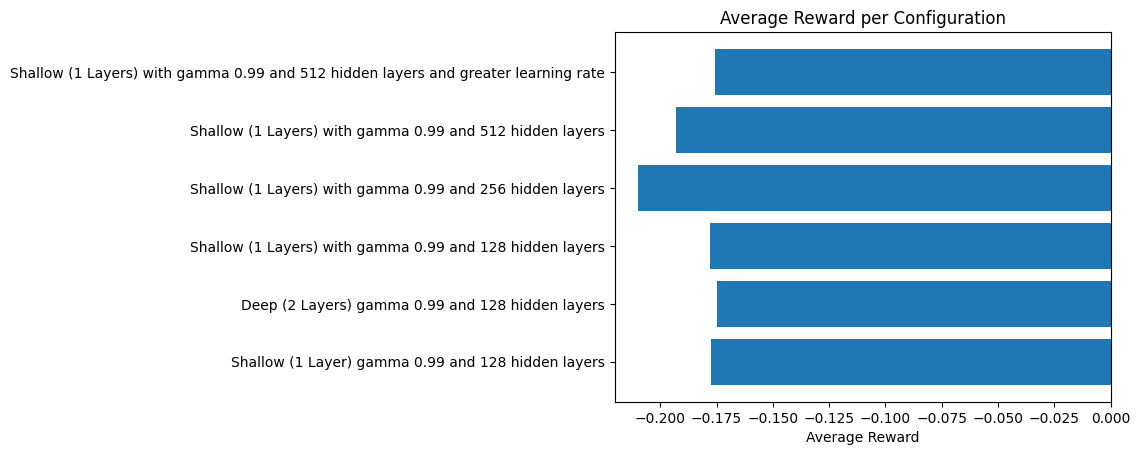

/tmp/ipython-input-3747047504.py:20: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


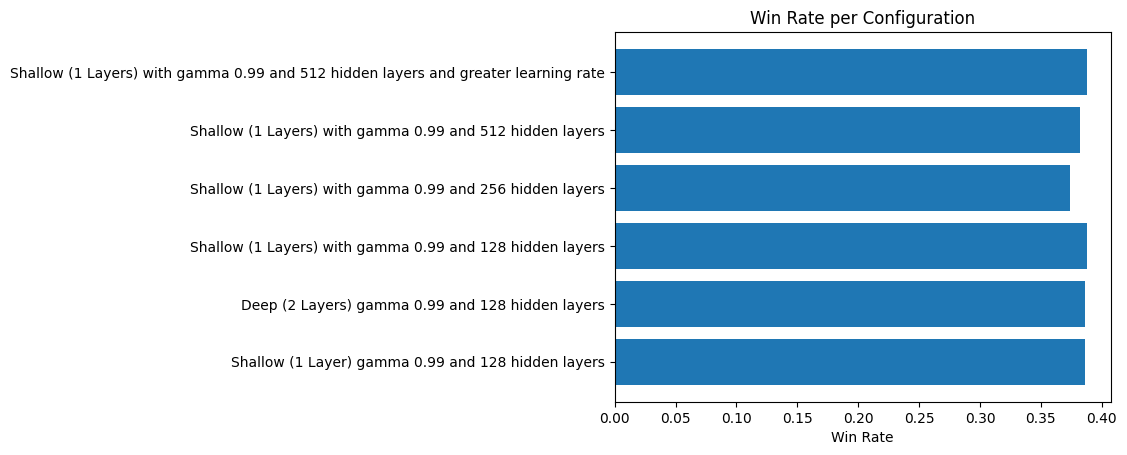

In [ ]:
import matplotlib.pyplot as plt

names = [r["name"] for r in results]
avg_rewards = [r["avg_reward"] for r in results]
win_rates = [r["win_rate"] for r in results]

# --- Average Reward ---
plt.figure()
plt.barh(names, avg_rewards)
plt.xlabel("Average Reward")
plt.title("Average Reward per Configuration")
plt.tight_layout()
plt.show()

# --- Win Rate ---
plt.figure()
plt.barh(names, win_rates)
plt.xlabel("Win Rate")
plt.title("Win Rate per Configuration")
plt.tight_layout()
plt.show()


Hyperparameter tuning with optuna

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 7.8 MB/s eta 0:00:00


In [ ]:
def objective(trial):
    # Hyperparameter search space
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    hidden_size = trial.suggest_categorical("hidden_size", [128, 256, 512])
    num_layers = trial.suggest_int("num_layers", 1, 3)
    gamma = trial.suggest_float("gamma", 0.9, 0.999)

    num_episodes = 15_000  # fixed for fair comparison

    # Create model
    model = ActorCriticLSTM(
        observation_space=env.observation_space,
        action_space=env.action_space,
        hidden_size=hidden_size,
        num_layers=num_layers
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # Train
    train_actor_critic_blackjack(
        model=model,
        optimizer=optimizer,
        env=env,
        num_episodes=num_episodes,
        gamma=gamma
    )

    # Evaluate (deterministic)
    avg_reward, win_rate = evaluate_agent(
        model=model,
        env=env,
        num_test_episodes=2000,
        device=device
    )

    # Optuna maximizes this value
    return win_rate


In [ ]:
import optuna

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print("Best trial:")
print(study.best_trial.params)
print("Best win rate:", study.best_value)

[I 2026-01-20 18:35:19,666] A new study created in memory with name: no-name-2df1888d-a5c8-4c62-80a9-e64cf2eba233


Episode 0 | Reward: -1.0 | Loss: 0.3737
Episode 1000 | Reward: 1.0 | Loss: 1.1475
Episode 2000 | Reward: 0.0 | Loss: -0.0003
Episode 3000 | Reward: 1.0 | Loss: 2.7663
Episode 4000 | Reward: -1.0 | Loss: 0.1325
Episode 5000 | Reward: -1.0 | Loss: 0.6273
Episode 6000 | Reward: -1.0 | Loss: 0.3161
Episode 7000 | Reward: 1.0 | Loss: 2.6499
Episode 8000 | Reward: -1.0 | Loss: 0.4303
Episode 9000 | Reward: -1.0 | Loss: 0.7265
Episode 10000 | Reward: -1.0 | Loss: 0.4355
Episode 11000 | Reward: 0.0 | Loss: 0.1077
Episode 12000 | Reward: 1.0 | Loss: 1.4197
Episode 13000 | Reward: -1.0 | Loss: 0.5164
Episode 14000 | Reward: 1.0 | Loss: 2.5766


[I 2026-01-20 18:41:46,035] Trial 0 finished with value: 0.387 and parameters: {'lr': 0.0028532378165418886, 'hidden_size': 512, 'num_layers': 1, 'gamma': 0.9823006683251329}. Best is trial 0 with value: 0.387.



Evaluation complete over 2000 episodes:
Average Reward: -0.1750
Win Rate: 38.70%
Episode 0 | Reward: -1.0 | Loss: 0.3059
Episode 1000 | Reward: -1.0 | Loss: 0.6509
Episode 2000 | Reward: -1.0 | Loss: 0.0955
Episode 3000 | Reward: 1.0 | Loss: 0.3339
Episode 4000 | Reward: -1.0 | Loss: 0.9649
Episode 5000 | Reward: -1.0 | Loss: 0.2560
Episode 6000 | Reward: 1.0 | Loss: 1.7368
Episode 7000 | Reward: 1.0 | Loss: 0.5244
Episode 8000 | Reward: 1.0 | Loss: 0.1831
Episode 9000 | Reward: -1.0 | Loss: 0.1517
Episode 10000 | Reward: 1.0 | Loss: 0.0236
Episode 11000 | Reward: 1.0 | Loss: 1.9755
Episode 12000 | Reward: -1.0 | Loss: 0.3310
Episode 13000 | Reward: 1.0 | Loss: 1.4622
Episode 14000 | Reward: -1.0 | Loss: 1.6216


[I 2026-01-20 19:04:03,312] Trial 1 finished with value: 0.401 and parameters: {'lr': 0.0003117603583398746, 'hidden_size': 512, 'num_layers': 3, 'gamma': 0.9942822311400488}. Best is trial 1 with value: 0.401.


...


Evaluation complete over 2000 episodes:
Average Reward: -0.0750
Win Rate: 41.60%
Episode 0 | Reward: -1.0 | Loss: 0.2184
Episode 1000 | Reward: 1.0 | Loss: 1.2484
Episode 2000 | Reward: -1.0 | Loss: 0.2841
Episode 3000 | Reward: 1.0 | Loss: 2.4139
Episode 4000 | Reward: 0.0 | Loss: 0.0047
Episode 5000 | Reward: 1.0 | Loss: 2.1417
Episode 6000 | Reward: -1.0 | Loss: 0.5115
Episode 7000 | Reward: -1.0 | Loss: 1.4494
Episode 8000 | Reward: 1.0 | Loss: 0.3820
Episode 9000 | Reward: 1.0 | Loss: 2.6937
Episode 10000 | Reward: 1.0 | Loss: 0.0027
Episode 11000 | Reward: 0.0 | Loss: 0.0199
Episode 12000 | Reward: 1.0 | Loss: 0.7576
Episode 13000 | Reward: -1.0 | Loss: -0.2403
Episode 14000 | Reward: 1.0 | Loss: 2.8275


[I 2026-01-20 21:08:23,546] Trial 28 finished with value: 0.385 and parameters: {'lr': 0.00020561847581746396, 'hidden_size': 128, 'num_layers': 2, 'gamma': 0.9204829302731597}. Best is trial 5 with value: 0.429.



Evaluation complete over 2000 episodes:
Average Reward: -0.1860
Win Rate: 38.50%
Episode 0 | Reward: 1.0 | Loss: 1.7396
Episode 1000 | Reward: 1.0 | Loss: 1.6940
Episode 2000 | Reward: -1.0 | Loss: 0.2205
Episode 3000 | Reward: -1.0 | Loss: 1.1308
Episode 4000 | Reward: -1.0 | Loss: 0.1367
Episode 5000 | Reward: -1.0 | Loss: 0.2308
Episode 6000 | Reward: 1.0 | Loss: 1.6331
Episode 7000 | Reward: 1.0 | Loss: 0.4699
Episode 8000 | Reward: 1.0 | Loss: 1.2365
Episode 9000 | Reward: 0.0 | Loss: 0.1570
Episode 10000 | Reward: -1.0 | Loss: 0.5090
Episode 11000 | Reward: -1.0 | Loss: 0.4123
Episode 12000 | Reward: -1.0 | Loss: 0.2589
Episode 13000 | Reward: 1.0 | Loss: 1.9160
Episode 14000 | Reward: 1.0 | Loss: 2.4990


[I 2026-01-20 21:31:35,864] Trial 29 finished with value: 0.4155 and parameters: {'lr': 0.00030724412949349067, 'hidden_size': 512, 'num_layers': 3, 'gamma': 0.934112496532289}. Best is trial 5 with value: 0.429.



Evaluation complete over 2000 episodes:
Average Reward: -0.1075
Win Rate: 41.55%
Best trial:
{'lr': 0.00015794972125733673, 'hidden_size': 256, 'num_layers': 3, 'gamma': 0.9051199270748657}
Best win rate: 0.429


In [ ]:
import matplotlib.pyplot as plt

# Extract completed trials
trials = [t for t in study.trials if t.value is not None]

win_rates = [t.value for t in trials]
lrs = [t.params["lr"] for t in trials]
gammas = [t.params["gamma"] for t in trials]
hidden_sizes = [t.params["hidden_size"] for t in trials]
num_layers = [t.params["num_layers"] for t in trials]


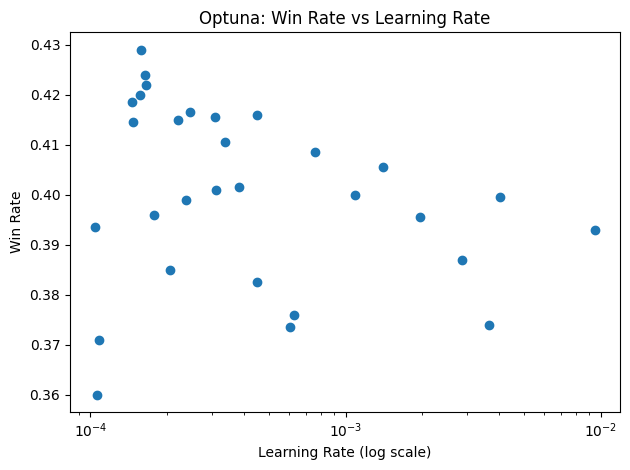

In [ ]:
plt.figure()
plt.scatter(lrs, win_rates)
plt.xscale("log")
plt.xlabel("Learning Rate (log scale)")
plt.ylabel("Win Rate")
plt.title("Optuna: Win Rate vs Learning Rate")
plt.tight_layout()
plt.show()


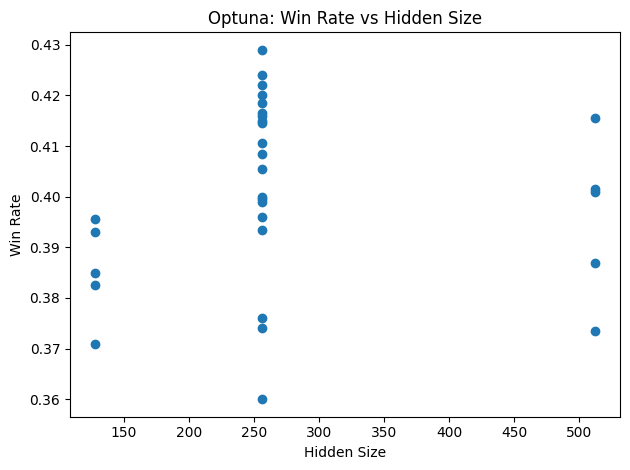

In [ ]:
plt.figure()
plt.scatter(hidden_sizes, win_rates)
plt.xlabel("Hidden Size")
plt.ylabel("Win Rate")
plt.title("Optuna: Win Rate vs Hidden Size")
plt.tight_layout()
plt.show()


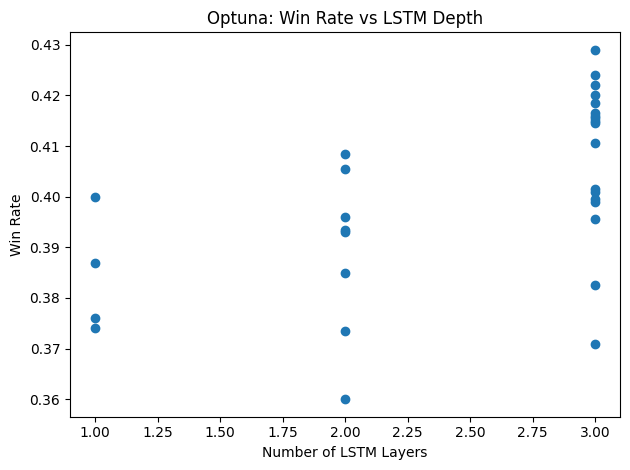

In [ ]:
plt.figure()
plt.scatter(num_layers, win_rates)
plt.xlabel("Number of LSTM Layers")
plt.ylabel("Win Rate")
plt.title("Optuna: Win Rate vs LSTM Depth")
plt.tight_layout()
plt.show()


In [ ]:
best = study.best_trial

print("\nBest Trial Summary")
print("------------------")
print(f"Win Rate: {best.value:.4f}")
for k, v in best.params.items():
    print(f"{k}: {v}")



Best Trial Summary
------------------
Win Rate: 0.4290
lr: 0.00015794972125733673
hidden_size: 256
num_layers: 3
gamma: 0.9051199270748657
